# Transaction Linking Experiment

**Goal**: Given a receipt/invoice image and a bank statement image, ask InternVL3 to identify
which debit transaction in the bank statement corresponds to the purchase on the receipt.

This is a **cross-document multi-image reasoning** task using concatenated pixel values.

In [1]:
"""Cell 1: Imports and sys.path setup."""

import re
import sys
from pathlib import Path

import torch
import yaml
from IPython.display import display
from PIL import Image

# Add project root to path so we can import from models/, common/, etc.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.pipeline_config import PipelineConfig  # noqa: E402
from common.simple_prompt_loader import SimplePromptLoader  # noqa: E402
from models.internvl3_image_preprocessor import InternVL3ImagePreprocessor  # noqa: E402
from models.registry import get_model  # noqa: E402

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Project root: /home/jovyan/nfs_share/tod_2026/LMM_POC
PyTorch: 2.5.1, CUDA: True


In [2]:
"""Cell 2: Load experiment config from YAML."""

config_path = PROJECT_ROOT / "config" / "experiment_config.yml"
with config_path.open() as f:
    exp_config = yaml.safe_load(f)

# Variant: "single" (default) or "multi_receipt"
variant = exp_config.get("experiment", {}).get("variant", "single")

# Extract base settings
model_type = exp_config["model"]["type"]
max_tiles = exp_config["model"]["max_tiles"]
max_new_tokens = exp_config["model"]["max_new_tokens"]
prompt_file = exp_config["prompts"]["file"]
prompt_key = exp_config["prompts"]["key"]
ground_truth = exp_config["ground_truth"]

# Overlay multi_receipt overrides when active
if variant == "multi_receipt":
    mr = exp_config.get("multi_receipt", {})
    max_tiles = mr.get("model", {}).get("max_tiles", max_tiles)
    max_new_tokens = mr.get("model", {}).get("max_new_tokens", max_new_tokens)
    prompt_key = mr.get("prompts", {}).get("key", prompt_key)
    ground_truth = mr.get("ground_truth", ground_truth)

# Data mode: "synthetic" or "real"
data_mode = exp_config["data"]["mode"]
data_dir = PROJECT_ROOT / exp_config["data"]["dir"]

print(f"Variant: {variant}")
print(f"Model: {model_type}, max_tiles: {max_tiles}, max_new_tokens: {max_new_tokens}")
print(f"Prompt: {prompt_file} -> {prompt_key}")
print(f"Data mode: {data_mode}")
print(f"Data dir: {data_dir}")

Variant: multi_receipt
Model: internvl3, max_tiles: 12, max_new_tokens: 1500
Prompt: transaction_linking.yaml -> link_receipt_page_to_statement
Data mode: synthetic
Data dir: /home/jovyan/nfs_share/tod_2026/LMM_POC/experiments/data


Generated multi-receipt page: /home/jovyan/nfs_share/tod_2026/LMM_POC/experiments/data/synthetic_multi_receipt_page.png


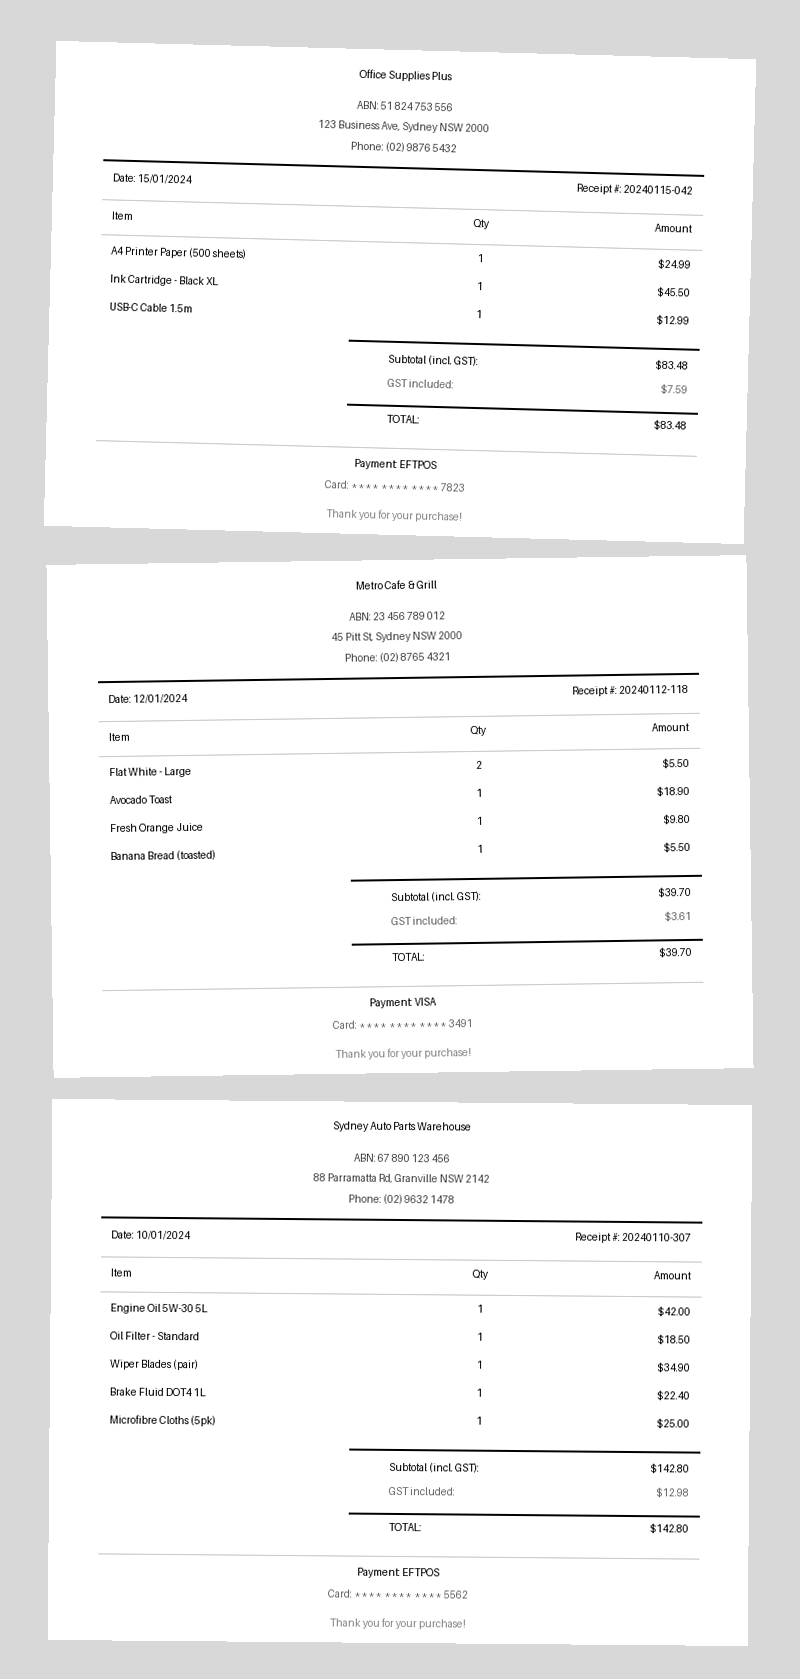

In [3]:
from experiments.synthetic.generate_multi_receipt_page import (
    generate_multi_receipt_page,
)
from experiments.synthetic.generate_receipt import generate_receipt

# Load or generate receipt image
if data_mode == "real":
    receipt_path = data_dir / exp_config["data"]["real_receipt"]
    if not receipt_path.exists():
        raise FileNotFoundError(f"Real receipt not found: {receipt_path}")
    print(f"Using real receipt: {receipt_path}")
elif variant == "multi_receipt":
    mr_filename = (
        exp_config.get("multi_receipt", {})
        .get("synthetic", {})
        .get("receipt", {})
        .get("filename", "synthetic_multi_receipt_page.png")
    )
    receipt_path = generate_multi_receipt_page(data_dir / mr_filename)
    print(f"Generated multi-receipt page: {receipt_path}")
else:
    receipt_path = generate_receipt(data_dir / "synthetic_receipt.png")
    print(f"Generated synthetic receipt: {receipt_path}")

receipt_img = Image.open(receipt_path)
display(receipt_img)

Generated synthetic bank statement: /home/jovyan/nfs_share/tod_2026/LMM_POC/experiments/data/synthetic_bank_statement.png


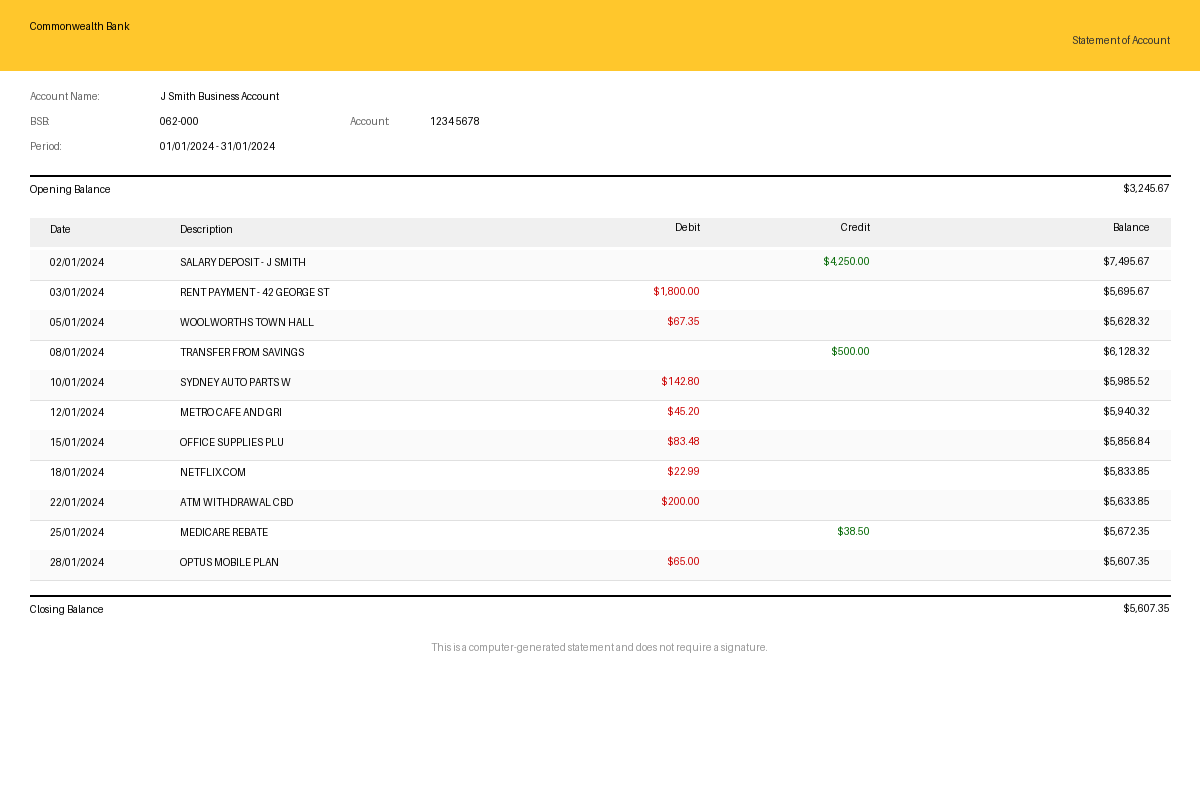

In [4]:
from experiments.synthetic.generate_bank_statement import generate_bank_statement

# Load or generate bank statement image
if data_mode == "real":
    statement_path = data_dir / exp_config["data"]["real_statement"]
    if not statement_path.exists():
        raise FileNotFoundError(f"Real bank statement not found: {statement_path}")
    print(f"Using real bank statement: {statement_path}")
else:
    statement_path = generate_bank_statement(data_dir / "synthetic_bank_statement.png")
    print(f"Generated synthetic bank statement: {statement_path}")

statement_img = Image.open(statement_path)
display(statement_img)

In [5]:
"""Cell 5: Load InternVL3 via registry context manager."""

# Build a minimal PipelineConfig for the model loader
run_config_path = PROJECT_ROOT / "config" / "run_config.yml"
with run_config_path.open() as f:
    run_config = yaml.safe_load(f)

# Resolve model path: explicit model.path first, then default_paths lookup
model_path = run_config.get("model", {}).get("path")
if not model_path:
    model_path = (
        run_config.get("model_loading", {}).get("default_paths", {}).get(model_type)
    )
if not model_path:
    raise FileNotFoundError(
        f"No model path found for '{model_type}' in run_config.yml. "
        "Set model.path or model_loading.default_paths.{model_type}."
    )
model_path = Path(model_path)
print(f"Model path: {model_path}")

cfg = PipelineConfig(
    data_dir=data_dir,
    output_dir=data_dir,
    model_path=model_path,
    model_type=model_type,
    max_tiles=max_tiles,
    flash_attn=exp_config["model"]["flash_attn"],
    dtype=exp_config["model"]["dtype"],
    max_new_tokens=max_new_tokens,
)

# Get loader from registry
registration = get_model(model_type)
model_ctx = registration.loader(cfg)
model, tokenizer = model_ctx.__enter__()
print(f"Model loaded: {type(model).__name__}")
print(f"Device: {next(model.parameters()).device}")

Model path: /home/jovyan/nfs_share/models/InternVL3_5-8B


Loading model from: /home/jovyan/nfs_share/models/InternVL3_5-8B

Output()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

⚡ Flash Attention 2: ✅ enabled

                          GPU Status                           
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ GPU          ┃   Total ┃ Allocated ┃ Reserved ┃ Utilization ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0: NVIDIA L4 │ 22.0 GB │  15.89 GB │ 15.92 GB │       72.3% │
└──────────────┴─────────┴───────────┴──────────┴─────────────┘

Model loaded: InternVLChatModel
Device: cuda:0


In [6]:
"""Cell 6: Preprocess both images — tile and concatenate pixel_values."""

preprocessor = InternVL3ImagePreprocessor(max_tiles=max_tiles)

# Load and tile each image
receipt_pv = preprocessor.load_image(str(receipt_path), model, max_num=max_tiles)
statement_pv = preprocessor.load_image(str(statement_path), model, max_num=max_tiles)

print(f"Receipt tiles: {receipt_pv.shape[0]}, Statement tiles: {statement_pv.shape[0]}")
print(f"Receipt pv shape: {receipt_pv.shape}")
print(f"Statement pv shape: {statement_pv.shape}")

# Concatenate pixel_values — each <image> tag maps to one image's patches
combined_pv = torch.cat([receipt_pv, statement_pv], dim=0)
num_patches = [receipt_pv.shape[0], statement_pv.shape[0]]

print(f"Combined shape: {combined_pv.shape}")
print(f"Num patches per image: {num_patches}")

Receipt tiles: 9, Statement tiles: 7
Receipt pv shape: torch.Size([9, 3, 448, 448])
Statement pv shape: torch.Size([7, 3, 448, 448])
Combined shape: torch.Size([16, 3, 448, 448])
Num patches per image: [9, 7]


In [7]:
"""Cell 7: Load linking prompt from YAML."""

linking_prompt = SimplePromptLoader.load_prompt(prompt_file, prompt_key)
print(f"Prompt key: {prompt_key}")
print(f"Prompt length: {len(linking_prompt)} chars")
print("---")
print(linking_prompt)

Prompt key: link_receipt_page_to_statement
Prompt length: 1562 chars
---
You are given two images:
- Image 1 is a scanned page that may contain MULTIPLE receipts
  (e.g. several receipts stapled or placed together on one page).
- Image 2 is a bank statement showing multiple transactions.

Your task has two steps:

STEP 1: Carefully examine Image 1 and enumerate every distinct receipt
visible on the page. Look for separate store names, dates, and totals
to distinguish individual receipts.

STEP 2: For EACH receipt found, identify the specific debit transaction
in the bank statement that corresponds to that purchase. Match on amount,
date, and merchant name.

Fuzzy matching hints:
- Bank statements often truncate merchant names (e.g. "Office Supplies Plus"
  becomes "OFFICE SUPPLIES PLU")
- The "&" symbol may appear as "AND" on the bank statement
- Names may be upper-cased and shortened to ~18-20 characters

For each receipt, respond in the following format:

--- RECEIPT 1 ---
MATCHED_TR

In [8]:
"""Cell 7b: Display the actual prompt sent to the model."""

question = f"<image>\n<image>\n{linking_prompt}"

print("Actual prompt sent to model.chat():")
print("=" * 60)
print(question)
print("=" * 60)
print(f"Total prompt length: {len(question)} chars")

Actual prompt sent to model.chat():
<image>
<image>
You are given two images:
- Image 1 is a scanned page that may contain MULTIPLE receipts
  (e.g. several receipts stapled or placed together on one page).
- Image 2 is a bank statement showing multiple transactions.

Your task has two steps:

STEP 1: Carefully examine Image 1 and enumerate every distinct receipt
visible on the page. Look for separate store names, dates, and totals
to distinguish individual receipts.

STEP 2: For EACH receipt found, identify the specific debit transaction
in the bank statement that corresponds to that purchase. Match on amount,
date, and merchant name.

Fuzzy matching hints:
- Bank statements often truncate merchant names (e.g. "Office Supplies Plus"
  becomes "OFFICE SUPPLIES PLU")
- The "&" symbol may appear as "AND" on the bank statement
- Names may be upper-cased and shortened to ~18-20 characters

For each receipt, respond in the following format:

--- RECEIPT 1 ---
MATCHED_TRANSACTION: FOUND or N

In [9]:
# Run multi-image inference with model.chat()
# InternVL3.5 .chat() expects generation_config as a dict, not GenerationConfig
generation_config = {
    "max_new_tokens": max_new_tokens,
    "do_sample": False,
    "num_beams": 1,
}

print("Running inference...")
response = model.chat(
    tokenizer,
    combined_pv,
    question,
    generation_config,
    num_patches_list=num_patches,
)
print("Inference complete.")

Running inference...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Inference complete.


In [10]:
"""Cell 9b: Display the raw model response."""

print("Raw model response:")
print("=" * 60)
print(response)
print("=" * 60)
print(f"Response length: {len(response)} chars")

Raw model response:
### Step 1: Enumerate Receipts

1. **Receipt 1**
   - Store: Office Supplies Plus
   - Date: 15/01/2024
   - Total: $83.48

2. **Receipt 2**
   - Store: MetroCafe & Grill
   - Date: 12/01/2024
   - Total: $39.70

3. **Receipt 3**
   - Store: Sydney Auto Parts Warehouse
   - Date: 10/01/2024
   - Total: $142.80

### Step 2: Match Transactions

#### Receipt 1
- **MATCHED_TRANSACTION:** FOUND
- **TRANSACTION_DATE:** 15/01/2024
- **TRANSACTION_AMOUNT:** $83.48
- **TRANSACTION_DESCRIPTION:** OFFICE SUPPLIES PLU
- **RECEIPT_STORE:** Office Supplies Plus
- **RECEIPT_TOTAL:** $83.48
- **CONFIDENCE:** HIGH
- **REASONING:** The amount and date match, and the merchant name is truncated in the bank statement.

#### Receipt 2
- **MATCHED_TRANSACTION:** FOUND
- **TRANSACTION_DATE:** 12/01/2024
- **TRANSACTION_AMOUNT:** $45.20
- **TRANSACTION_DESCRIPTION:** METROCAFE ANDGRI
- **RECEIPT_STORE:** MetroCafe & Grill
- **RECEIPT_TOTAL:** $39.70
- **CONFIDENCE:** MEDIUM
- **REASONING:**

In [11]:
"""Cell 9: Parse response — regex key-value extraction."""


def parse_kv_response(text: str) -> dict[str, str]:
    """Extract KEY: VALUE pairs from model response."""
    pattern = re.compile(r"^([A-Z_]+):\s*(.+)$", re.MULTILINE)
    return {m.group(1): m.group(2).strip() for m in pattern.finditer(text)}


def parse_multi_receipt_response(text: str) -> list[dict[str, str]]:
    """Split response on --- RECEIPT N --- headers and parse each section."""
    sections = re.split(r"---\s*RECEIPT\s+\d+\s*---", text)
    # First element is text before the first header (usually empty)
    results = []
    for section in sections[1:]:
        parsed = parse_kv_response(section)
        if parsed:
            results.append(parsed)
    return results


if variant == "multi_receipt":
    parsed_receipts = parse_multi_receipt_response(response)
    print(f"Parsed {len(parsed_receipts)} receipt sections:")
    for i, p in enumerate(parsed_receipts, 1):
        print(f"\n--- Receipt {i} ---")
        for key, value in p.items():
            print(f"  {key}: {value}")
else:
    parsed = parse_kv_response(response)
    print(f"Extracted {len(parsed)} fields:")
    for key, value in parsed.items():
        print(f"  {key}: {value}")

Parsed 0 receipt sections:


In [12]:
"""Cell 10: Validate against ground truth."""

print("Validation Results")
print("=" * 60)
all_pass = True

if variant == "multi_receipt":
    # Match parsed receipts to ground truth by RECEIPT_TOTAL
    gt_list = ground_truth  # list of dicts from config
    gt_by_total = {gt["receipt_total"]: gt for gt in gt_list}

    matched_count = 0
    for i, parsed_r in enumerate(parsed_receipts, 1):
        total_key = parsed_r.get("RECEIPT_TOTAL", "")
        gt_match = gt_by_total.get(total_key)
        print(f"\n--- Receipt {i} (total: {total_key}) ---")
        if gt_match is None:
            print(f"  [WARN] No ground truth entry for total '{total_key}'")
            all_pass = False
            continue
        matched_count += 1
        gt_norm = {k.upper(): v for k, v in gt_match.items()}
        for field, expected in gt_norm.items():
            actual = parsed_r.get(field, "MISSING")
            match = actual.upper() == expected.upper()
            status = "PASS" if match else "FAIL"
            if not match:
                all_pass = False
            print(f"  [{status}] {field}: expected='{expected}' got='{actual}'")

    if matched_count < len(gt_list):
        all_pass = False
        print(f"\n  [FAIL] Only matched {matched_count}/{len(gt_list)} receipts")
else:
    gt_normalised = {k.upper(): v for k, v in ground_truth.items()}
    for field, expected in gt_normalised.items():
        actual = parsed.get(field, "MISSING")
        match = actual.upper() == expected.upper()
        status = "PASS" if match else "FAIL"
        if not match:
            all_pass = False
        print(f"  [{status}] {field}: expected='{expected}' got='{actual}'")

print("=" * 60)
if all_pass:
    print("ALL FIELDS MATCH — experiment passed.")
else:
    print("SOME FIELDS DID NOT MATCH — review above.")

Validation Results

  [FAIL] Only matched 0/3 receipts
SOME FIELDS DID NOT MATCH — review above.


In [13]:
import gc

# Cleanup — free GPU memory
try:
    model_ctx.__exit__(None, None, None)
except Exception:
    pass

# Belt-and-braces cleanup
del combined_pv, receipt_pv, statement_pv
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("Cleanup complete.")

GPU memory allocated: 17.07 GB
Cleanup complete.
